<a href="https://colab.research.google.com/github/komorimasashi/HIS2024-GenAI/blob/main/Title_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLMによる分散表現の取得

## 解説

講演のタイトル同士の関係をLLMによる埋め込み表現（分散表現）を使って調べてみましょう．

Geminiのembeddigモデル（`text-embedding-004`）は残念ながら日本語に対応していないので，一旦すべてのタイトルを`gemini-1.5-pro`で英語に翻訳してから，埋め込み表現を取得します．埋め込み表現は768次元もあるため，主成分分析で2次元に縮約した後にプロットします．

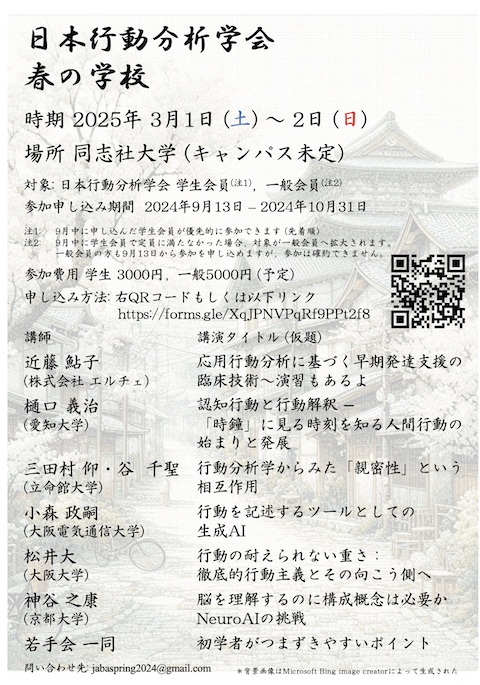

**GeminiのAPIキーを使う方法**

*   左のツールバーにある「鍵」アイコンをクリック
*   「Gemni APIキー」から「Google AI Studioからキーをインポート」を選択→「インポート」
*   下のようにAPIキーが登録されたはず


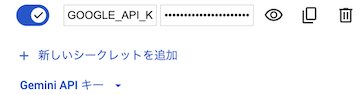

## プログラム

日本語が使えるようにする

In [178]:
!apt-get -y install fonts-ipafont-gothic
!pip install japanize-matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.


ライブラリの読み込み

In [179]:
import os
import pandas as pd
import google.generativeai as genai
from google.colab import userdata
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
import time

「春の学校」の発表タイトルをリストにまとめる

In [180]:
titles = [
    "応用行動分析に基づく早期発達支援の臨床技術～演習もあるよ",
    "認知行動と行動解釈 −「時鐘」に見る時刻を知る人間行動の始まりと発展",
    "行動分析学からみた「親密性」という相互作用",
    "行動を記述するツールとしての生成AI",
    "行動の耐えられない重さ：徹底的行動主義とその向こう側へ",
    "脳を理解するのに構成概念は必要か：NeuroAIの挑戦",
    "初学者がつまずきやすいポイント"
]

# タイトルをDataFrameに変換
df = pd.DataFrame({'title': titles})

Gemini の生成モデルを使ってテキストを英語に翻訳する関数

In [181]:
def translate_to_english(text):
    model = genai.GenerativeModel("gemini-1.5-pro")
    prompt = f"Translate the following text into English:\n\n{text}"

    try:
        response = model.generate_content(prompt)
        time.sleep(10)  # APIの連続呼び出し対策
        return response.text.strip()
    except Exception as e:
        print(f"Translation error for text: {text}\n{e}")
        return None

text-embedding-004（非多言語モデル） を使ってテキストの埋め込みを取得する関数

In [182]:
def get_embedding(text):
    try:
        result = genai.embed_content(
            model="models/text-embedding-004",
            content=text
        )
        # API連続呼び出し対策として10秒待機
        time.sleep(10)
        return result['embedding']
    except Exception as e:
        print(f"Error for text: {text}\n{e}")
        return None

テキストをまず英語に翻訳し、翻訳結果を使って埋め込みを取得する関数

In [183]:
def get_embedding_with_translation(text):
    english_text = translate_to_english(text)
    if english_text is None:
        return None
    print(f"Translated text: {english_text}")
    embedding = get_embedding(english_text)
    return embedding

埋め込みの実行

In [184]:
# Gemini APIの設定
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

In [185]:
# 各タイトルの埋め込み表現を取得（各行に対してget_embedding関数を適用）
embeddings = df['title'].apply(get_embedding_with_translation)
embeddings = np.array(embeddings.tolist())

Translated text: Clinical Techniques in Early Intervention Based on Applied Behavior Analysis (ABA) ~Includes Practical Exercises~
Translated text: Cognitive Behavior and the Interpretation of Behavior - The Beginning and Development of Human Behavior in Telling Time, as Seen Through the "Clock"
Translated text: "Intimacy" as an Interaction: An Applied Behavior Analysis Perspective
Translated text: Generative AI as a tool for describing actions.
Translated text: The Unbearable Lightness of Action: Radical Behaviorism and Beyond
Translated text: Are Conceptual Representations Necessary for Understanding the Brain?: The Challenge of NeuroAI
Translated text: Common pitfalls for beginners / Points beginners often struggle with / Areas where beginners tend to get stuck.


768次元のデータを２次元に縮約してプロット

In [186]:
# PCAで2次元に縮約
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# PCA結果をDataFrameに追加
df['pca1'] = embeddings_2d[:, 0]
df['pca2'] = embeddings_2d[:, 1]

In [187]:
# フォントの設定
plt.rcParams['font.family'] = 'IPAPGothic'
japanize_matplotlib.japanize()

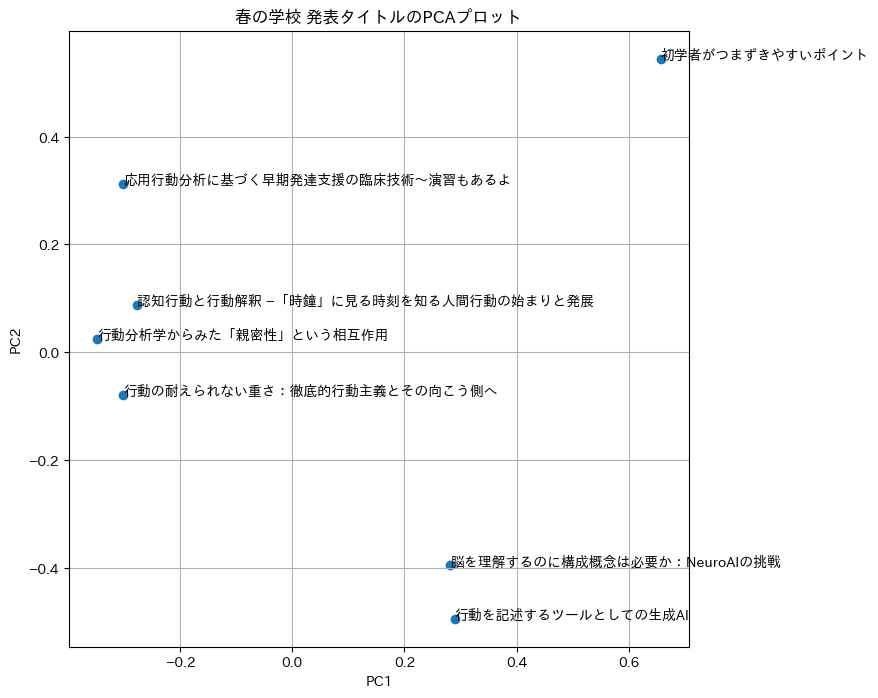

In [188]:
# プロット
plt.figure(figsize=(8,8))
plt.scatter(df['pca1'], df['pca2'], marker='o')
# 各点にタイトルのラベルを表示
for i, txt in enumerate(df['title']):
    plt.annotate(txt, (df['pca1'][i], df['pca2'][i]))

plt.title("春の学校 発表タイトルのPCAプロット")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [189]:
df

,title,pca1,pca2
0,応用行動分析に基づく早期発達支援の臨床技術～演習もあるよ,-0.301564,0.313107
1,認知行動と行動解釈 −「時鐘」に見る時刻を知る人間行動の始まりと発展,-0.277272,0.087213
2,行動分析学からみた「親密性」という相互作用,-0.348176,0.025040
3,行動を記述するツールとしての生成AI,0.289865,-0.494586
4,行動の耐えられない重さ：徹底的行動主義とその向こう側へ,-0.301664,-0.079768
5,脳を理解するのに構成概念は必要か：NeuroAIの挑戦,0.281547,-0.395760
6,初学者がつまずきやすいポイント,0.657264,0.544754
